# Experiment 1 — Basic Sequence-to-Sequence Translation (English → French)

 build the foundational LSTM encoder–decoder that later experiments extend.



## 0. Setup

In [4]:
import re, math, time, random, subprocess, sys, collections, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

try:
    import sacrebleu
except ImportError:  # optional: falls back to NLTK if the install is not possible
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sacrebleu"])
        import sacrebleu
    except Exception:
        sacrebleu = None
        print("sacrebleu unavailable -> using nltk corpus_bleu for scoring")

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
DEVICE = "/GPU:0" if tf.config.list_physical_devices("GPU") else "/CPU:0"   # TF places ops on the GPU automatically
print("device:", DEVICE)

device: /GPU:0


## 1. Configuration

In [5]:
class CFG:
    # data
    data_dir   = next((p for p in [Path("."), Path("data"), Path("/mnt/user-data/uploads")]
                       if (p / "en_fr_train.csv").exists()), Path("."))
    max_len    = 40        # drop training pairs longer than this (tokens, either side)
    max_vocab  = 16000     # per language, incl. 4 special tokens
    min_freq   = 2         # rarer words become <unk>
    # model
    emb_dim    = 256
    hid_dim    = 512
    n_layers   = 2
    dropout    = 0.3
    # training
    batch_size = 128
    lr         = 1e-3
    epochs     = 12
    clip       = 1.0
    patience   = 3         # early-stopping patience (epochs) on val loss
    # decoding
    max_decode_len = 80

QUICK_RUN = False   # True -> tiny subset + 2 epochs, just to smoke-test the notebook
if QUICK_RUN:
    CFG.epochs = 2
print("data dir:", CFG.data_dir.resolve())

data dir: /content


## 2. Load & clean the data

In [6]:
def load_split(name):
    df = pd.read_csv(CFG.data_dir / f"en_fr_{name}.csv")
    df = df.dropna().astype(str)
    df["en"] = df["en"].str.strip(); df["fr"] = df["fr"].str.strip()
    return df[(df.en != "") & (df.fr != "")].reset_index(drop=True)

train_df, val_df, test_df = (load_split(s) for s in ["train", "val", "test"])
n_dup = train_df.duplicated().sum()
train_df = train_df.drop_duplicates().reset_index(drop=True)   # duplicates inflate memorisation
if QUICK_RUN:
    train_df = train_df.sample(20000, random_state=SEED).reset_index(drop=True)
    test_df  = test_df.sample(500, random_state=SEED).reset_index(drop=True)

print(f"train {len(train_df):,} (removed {n_dup:,} duplicates) | val {len(val_df):,} | test {len(test_df):,}")
train_df.sample(3, random_state=1)

train 230,771 (removed 2,054 duplicates) | val 890 | test 8,597


,en,fr
120274,I was very fortunate early in my career.,J'étais très chanceux au commencement de ma ca...
110625,Because if somebody could find a way to restor...,Parce que si quelqu'un pouvait trouver un moye...
59074,One. Great. Okay.,Une. Correct.


## 3. Tokenisation & vocabularies
Word-level, lower-cased, punctuation split off (`l'année` → `l ' année`). The same tokeniser is used for model input **and** for BLEU, so scores are consistent.
Words outside the vocabulary become `<unk>` — this is exactly where the basic model will struggle with rare words.

In [7]:
TOKEN_RE = re.compile(r"\w+|[^\w\s]", re.UNICODE)
def tokenize(text): return TOKEN_RE.findall(text.lower())

PAD, SOS, EOS, UNK = 0, 1, 2, 3
SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]

class Vocab:
    def __init__(self, token_lists, max_size, min_freq):
        counts = collections.Counter(t for toks in token_lists for t in toks)
        words = [w for w, c in counts.most_common(max_size - len(SPECIALS)) if c >= min_freq]
        self.itos = SPECIALS + words
        self.stoi = {w: i for i, w in enumerate(self.itos)}
        self.total, self.covered = sum(counts.values()), sum(counts[w] for w in words)
    def encode(self, toks): return [self.stoi.get(t, UNK) for t in toks]
    def decode(self, ids):  return [self.itos[i] for i in ids]
    def __len__(self): return len(self.itos)

for df in (train_df, val_df, test_df):
    df["en_tok"] = df.en.map(tokenize); df["fr_tok"] = df.fr.map(tokenize)

# length filter on TRAIN only (val/test stay untouched so the evaluation is honest)
keep = (train_df.en_tok.str.len().between(1, CFG.max_len)) & (train_df.fr_tok.str.len().between(1, CFG.max_len))
print(f"train pairs kept after length filter (<= {CFG.max_len} tokens): {keep.sum():,} / {len(train_df):,}")
train_df = train_df[keep].reset_index(drop=True)

src_vocab = Vocab(train_df.en_tok, CFG.max_vocab, CFG.min_freq)
tgt_vocab = Vocab(train_df.fr_tok, CFG.max_vocab, CFG.min_freq)
print(f"EN vocab {len(src_vocab):,} (token coverage {src_vocab.covered/src_vocab.total:.2%})")
print(f"FR vocab {len(tgt_vocab):,} (token coverage {tgt_vocab.covered/tgt_vocab.total:.2%})")

train pairs kept after length filter (<= 40 tokens): 200,245 / 230,771
EN vocab 16,000 (token coverage 98.35%)
FR vocab 16,000 (token coverage 97.35%)


## 4. Datasets & data loaders

In [8]:
def pad_sequence(seqs, batch_first=True, padding_value=PAD):
    """numpy replacement for torch's pad_sequence: right-pad to the longest sequence in the batch."""
    out = np.full((len(seqs), max(len(s) for s in seqs)), padding_value, dtype=np.int32)
    for i, s in enumerate(seqs): out[i, :len(s)] = s
    return out

class ParallelDataset:
    def __init__(self, df):
        # source: tokens + <eos>;  target: <sos> + tokens + <eos>
        self.src = [np.array(src_vocab.encode(t) + [EOS], dtype=np.int32) for t in df.en_tok]
        self.tgt = [np.array([SOS] + tgt_vocab.encode(t) + [EOS], dtype=np.int32) for t in df.fr_tok]
    def __len__(self): return len(self.src)
    def __getitem__(self, i): return self.src[i], self.tgt[i]

def collate(batch):
    src, tgt = zip(*batch)
    lens = np.array([len(s) for s in src], dtype=np.int32)
    return pad_sequence(src, batch_first=True, padding_value=PAD), lens, \
           pad_sequence(tgt, batch_first=True, padding_value=PAD)

class DataLoader:
    """Minimal stand-in for torch's DataLoader: reshuffles every epoch, yields collated batches."""
    def __init__(self, dataset, batch_size, shuffle=False, collate_fn=collate):
        self.dataset, self.batch_size, self.shuffle, self.collate_fn = dataset, batch_size, shuffle, collate_fn
    def __len__(self): return math.ceil(len(self.dataset) / self.batch_size)
    def __iter__(self):
        idx = np.random.permutation(len(self.dataset)) if self.shuffle else np.arange(len(self.dataset))
        for b in range(0, len(idx), self.batch_size):
            yield self.collate_fn([self.dataset[i] for i in idx[b:b + self.batch_size]])

train_dl = DataLoader(ParallelDataset(train_df), CFG.batch_size, shuffle=True,  collate_fn=collate)
val_dl   = DataLoader(ParallelDataset(val_df),   CFG.batch_size, shuffle=False, collate_fn=collate)
print("train batches:", len(train_dl))

train batches: 1565


## 5. Model — LSTM encoder–decoder

```
 source tokens ──► [Embedding] ─► [LSTM encoder] ─► final (h, c)  ← fixed-size context
                                                        │
 <sos> y1 y2 … ──► [Embedding] ─► [LSTM decoder, init = (h, c)] ─► [Linear] ─► P(next word)
```

In [9]:
class Encoder(keras.Model):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.emb  = layers.Embedding(vocab_size, emb_dim)
        self.rnns = [layers.LSTM(hid_dim, return_sequences=True, return_state=True) for _ in range(n_layers)]
        self.drop = layers.Dropout(dropout)
        self.inter_drop = layers.Dropout(dropout if n_layers > 1 else 0.0)   # dropout between LSTM layers (nn.LSTM(dropout=...))
    def call(self, src, lens, training=False):
        mask = tf.sequence_mask(lens, maxlen=tf.shape(src)[1])               # True on real tokens (replaces pack_padded_sequence)
        x = self.emb(src) * tf.cast(mask, tf.float32)[..., None]             # <pad> -> zero vector (torch padding_idx)
        x = self.drop(x, training=training)
        hs, cs = [], []
        for i, rnn in enumerate(self.rnns):
            x, h, c = rnn(x, mask=mask)       # state is frozen on padded steps -> h, c are at the true last token
            hs.append(h); cs.append(c)
            if i < len(self.rnns) - 1: x = self.inter_drop(x, training=training)
        return tf.stack(hs), tf.stack(cs)     # each: (n_layers, B, hid)

class Decoder(keras.Model):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.emb  = layers.Embedding(vocab_size, emb_dim)
        self.rnns = [layers.LSTM(hid_dim, return_sequences=True, return_state=True) for _ in range(n_layers)]
        self.drop = layers.Dropout(dropout)
        self.inter_drop = layers.Dropout(dropout if n_layers > 1 else 0.0)   # dropout between LSTM layers (nn.LSTM(dropout=...))
        self.out  = layers.Dense(vocab_size)
    def call(self, tgt_in, state, training=False):
        h0, c0 = state
        x = self.emb(tgt_in) * tf.cast(tf.not_equal(tgt_in, PAD), tf.float32)[..., None]
        x = self.drop(x, training=training)
        hs, cs = [], []
        for i, rnn in enumerate(self.rnns):
            x, h, c = rnn(x, initial_state=[h0[i], c0[i]])
            hs.append(h); cs.append(c)
            if i < len(self.rnns) - 1: x = self.inter_drop(x, training=training)
        return self.out(self.drop(x, training=training)), (tf.stack(hs), tf.stack(cs))  # logits: (B, T, V)

class Seq2Seq(keras.Model):
    def __init__(self, enc, dec):
        super().__init__(); self.encoder, self.decoder = enc, dec
    def call(self, src, lens, tgt_in, training=False):     # teacher forcing: feed the gold previous token
        state = self.encoder(src, lens, training=training)
        logits, _ = self.decoder(tgt_in, state, training=training)
        return logits

def build_model():
    enc = Encoder(len(src_vocab), CFG.emb_dim, CFG.hid_dim, CFG.n_layers, CFG.dropout)
    dec = Decoder(len(tgt_vocab), CFG.emb_dim, CFG.hid_dim, CFG.n_layers, CFG.dropout)
    m = Seq2Seq(enc, dec)
    m(tf.ones((1, 2), tf.int32), tf.constant([2], tf.int32), tf.ones((1, 2), tf.int32))   # dummy pass -> creates the weights
    for p in m.trainable_variables:           # small uniform init, as in Sutskever et al.
        if len(p.shape) > 1: p.assign(tf.random.uniform(p.shape, -0.08, 0.08))
    return m

model = build_model()
print(f"trainable parameters: {sum(int(np.prod(p.shape)) for p in model.trainable_variables):,}")

trainable parameters: 23,748,224


## 6. Training

In [10]:
def criterion(labels, logits):
    """Cross-entropy averaged over non-<pad> targets (same as nn.CrossEntropyLoss(ignore_index=PAD))."""
    ce = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)
    keep = tf.cast(tf.not_equal(labels, PAD), ce.dtype)
    return tf.reduce_sum(ce * keep) / tf.reduce_sum(keep)

class ReduceLROnPlateau:
    """Same rule as torch.optim.lr_scheduler.ReduceLROnPlateau (mode='min', rel. threshold 1e-4)."""
    def __init__(self, optimizer, factor=0.5, patience=1, threshold=1e-4, eps=1e-8):
        self.opt, self.factor, self.patience, self.threshold, self.eps = optimizer, factor, patience, threshold, eps
        self.lr, self.best, self.bad = float(CFG.lr), float("inf"), 0
    def step(self, metric):
        if metric < self.best * (1 - self.threshold): self.best, self.bad = metric, 0
        else: self.bad += 1
        if self.bad > self.patience:
            new = self.lr * self.factor
            if self.lr - new > self.eps:
                self.lr = new; self.opt.learning_rate.assign(new)
            self.bad = 0

_sig = [tf.TensorSpec([None, None], tf.int32),   # src
        tf.TensorSpec([None],       tf.int32),   # lens
        tf.TensorSpec([None, None], tf.int32)]   # tgt

optimizer = keras.optimizers.Adam(learning_rate=CFG.lr, epsilon=1e-8)     # eps matches torch.optim.Adam
scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=1)

@tf.function(input_signature=_sig)
def train_step(src, lens, tgt):
    with tf.GradientTape() as tape:
        logits = model(src, lens, tgt[:, :-1], training=True)                # predict tokens 1..T
        loss = criterion(tgt[:, 1:], logits)
    grads = tape.gradient(loss, model.trainable_variables)
    grads = [tf.convert_to_tensor(g) for g in grads]                         # dense grads (embedding grads are IndexedSlices)
    grads, _ = tf.clip_by_global_norm(grads, CFG.clip)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

@tf.function(input_signature=_sig)
def eval_step(src, lens, tgt):
    logits = model(src, lens, tgt[:, :-1], training=False)
    return criterion(tgt[:, 1:], logits)

def run_epoch(loader, train):
    total, n = 0.0, 0
    for src, lens, tgt in loader:
        total += float((train_step if train else eval_step)(src, lens, tgt)); n += 1
    return total / n

history = {"train_loss": [], "val_loss": []}
best_val, bad_epochs, best_state = float("inf"), 0, None

for epoch in range(1, CFG.epochs + 1):
    t0 = time.time()
    tr = run_epoch(train_dl, True)
    va = run_epoch(val_dl, False)
    scheduler.step(va)
    history["train_loss"].append(tr); history["val_loss"].append(va)
    flag = ""
    if va < best_val:
        best_val, bad_epochs, flag = va, 0, "  * best"
        best_state = model.get_weights()
    else:
        bad_epochs += 1
    print(f"epoch {epoch:2d} | train loss {tr:.3f} (ppl {math.exp(tr):6.1f}) | "
          f"val loss {va:.3f} (ppl {math.exp(va):6.1f}) | {time.time()-t0:5.0f}s{flag}")
    if bad_epochs >= CFG.patience:
        print("early stopping"); break

model.set_weights(best_state)
with open("seq2seq_basic.pkl", "wb") as f:      # .pt (torch.save) -> pickle of the numpy weight list
    pickle.dump({"model": best_state, "cfg": {k: v for k, v in vars(CFG).items() if not k.startswith("_") and not isinstance(v, Path)},
                 "src_itos": src_vocab.itos, "tgt_itos": tgt_vocab.itos}, f)
print("restored best checkpoint (val loss %.3f) and saved seq2seq_basic.pkl" % best_val)

epoch  1 | train loss 4.418 (ppl   82.9) | val loss 3.904 (ppl   49.6) |   394s  * best
epoch  2 | train loss 3.515 (ppl   33.6) | val loss 3.520 (ppl   33.8) |   402s  * best
epoch  3 | train loss 3.126 (ppl   22.8) | val loss 3.313 (ppl   27.5) |   403s  * best
epoch  4 | train loss 2.858 (ppl   17.4) | val loss 3.155 (ppl   23.5) |   403s  * best
epoch  5 | train loss 2.658 (ppl   14.3) | val loss 3.064 (ppl   21.4) |   403s  * best
epoch  6 | train loss 2.500 (ppl   12.2) | val loss 2.990 (ppl   19.9) |   404s  * best
epoch  7 | train loss 2.372 (ppl   10.7) | val loss 2.915 (ppl   18.5) |   404s  * best
epoch  8 | train loss 2.264 (ppl    9.6) | val loss 2.874 (ppl   17.7) |   403s  * best
epoch  9 | train loss 2.175 (ppl    8.8) | val loss 2.858 (ppl   17.4) |   403s  * best
epoch 10 | train loss 2.099 (ppl    8.2) | val loss 2.831 (ppl   17.0) |   402s  * best
epoch 11 | train loss 2.034 (ppl    7.6) | val loss 2.817 (ppl   16.7) |   403s  * best
epoch 12 | train loss 1.977 (ppl

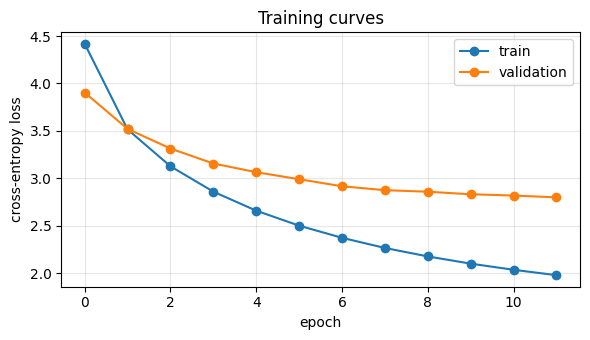

In [11]:
plt.figure(figsize=(6, 3.5))
plt.plot(history["train_loss"], marker="o", label="train")
plt.plot(history["val_loss"],   marker="o", label="validation")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss"); plt.title("Training curves")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 7. Inference (greedy decoding)
Encode the source once, then feed the decoder `<sos>` and repeatedly pick the most probable next word until `<eos>` or the length cap.

In [12]:
def translate_tokens(src_token_lists, batch_size=128):
    """Translate a list of tokenised English sentences -> list of French token lists."""
    order = sorted(range(len(src_token_lists)), key=lambda i: len(src_token_lists[i]))  # similar lengths per batch
    results = [None] * len(src_token_lists)
    for b in range(0, len(order), batch_size):
        idx = order[b:b + batch_size]
        seqs = [np.array(src_vocab.encode(src_token_lists[i][:100]) + [EOS], dtype=np.int32) for i in idx]
        lens = tf.constant([len(s) for s in seqs], dtype=tf.int32)
        src = tf.constant(pad_sequence(seqs, batch_first=True, padding_value=PAD))
        state = model.encoder(src, lens)
        inp = tf.fill((len(idx), 1), SOS)
        out, done = [], tf.zeros(len(idx), tf.bool)
        for _ in range(CFG.max_decode_len):
            logits, state = model.decoder(inp, state)
            nxt = tf.argmax(logits[:, -1], axis=-1, output_type=tf.int32)
            out.append(nxt); done = tf.logical_or(done, tf.equal(nxt, EOS))
            if bool(tf.reduce_all(done)): break
            inp = nxt[:, None]
        out = tf.stack(out, 1).numpy().tolist()
        for i, ids in zip(idx, out):
            ids = ids[:ids.index(EOS)] if EOS in ids else ids
            results[i] = tgt_vocab.decode(ids)
    return results

def translate(sentence):
    return " ".join(translate_tokens([tokenize(sentence)])[0])

for s in ["Thank you very much.", "I think this is a very important question.",
          "We have to change the way we think about energy."]:
    print(f"EN: {s}\nFR: {translate(s)}\n")

EN: Thank you very much.
FR: merci beaucoup .

EN: I think this is a very important question.
FR: je pense que c ' est une question très importante .

EN: We have to change the way we think about energy.
FR: nous devons changer la façon dont nous pensons à l ' énergie .



## 8. Evaluation — BLEU on the held-out test split
Corpus-level BLEU (0–100) with SacreBLEU, computed on the same lower-cased word tokens the model uses (`tokenize='none'`, so no hidden re-tokenisation).

In [13]:
def bleu(hyps, refs):
    """hyps, refs: lists of token lists. Returns corpus BLEU on a 0-100 scale."""
    if sacrebleu is not None:
        return sacrebleu.corpus_bleu([" ".join(h) for h in hyps],
                                     [[" ".join(r) for r in refs]], tokenize="none").score
    from nltk.translate.bleu_score import corpus_bleu
    return 100 * corpus_bleu([[r] for r in refs], hyps)

t0 = time.time()
test_df["hyp_tok"] = translate_tokens(list(test_df.en_tok))
test_bleu = bleu(list(test_df.hyp_tok), list(test_df.fr_tok))
print(f"decoded {len(test_df):,} sentences in {time.time()-t0:.0f}s")
print(f"\n>>> TEST BLEU = {test_bleu:.2f}")

decoded 8,597 sentences in 84s

>>> TEST BLEU = 16.57


## 9. Failure-mode analysis
Where does the basic model break? We slice the test set by **source length**, by the **number of unknown words**, and look for **repetition** and **length mismatch**.

In [14]:
test_df["src_len"] = test_df.en_tok.str.len()
test_df["hyp_len"] = test_df.hyp_tok.str.len()
test_df["ref_len"] = test_df.fr_tok.str.len()
test_df["n_unk"]   = test_df.en_tok.map(lambda t: sum(src_vocab.stoi.get(w, UNK) == UNK for w in t))

def has_repeat(toks, n=3):
    grams = [tuple(toks[i:i+n]) for i in range(len(toks) - n + 1)]
    return len(grams) != len(set(grams))
test_df["repeats"] = test_df.hyp_tok.map(has_repeat)

def slice_report(df, col, bins, labels):
    g = pd.cut(df[col], bins=bins, labels=labels)
    rows = []
    for lab in labels:
        sub = df[g == lab]
        if len(sub) < 20: continue
        rows.append({col: lab, "n": len(sub),
                     "BLEU": bleu(list(sub.hyp_tok), list(sub.fr_tok)),
                     "len ratio (hyp/ref)": sub.hyp_len.sum() / sub.ref_len.sum(),
                     "% with repeated 3-grams": 100 * sub.repeats.mean()})
    return pd.DataFrame(rows).round(2)

len_report = slice_report(test_df, "src_len", [0, 10, 20, 30, 40, 1000], ["1-10", "11-20", "21-30", "31-40", "41+"])
unk_report = slice_report(test_df, "n_unk",   [-1, 0, 1, 2, 1000],       ["0", "1", "2", "3+"])
print("BLEU by source length"); display(len_report)
print("BLEU by # of unknown source words"); display(unk_report)

BLEU by source length


,src_len,n,BLEU,len ratio (hyp/ref),% with repeated 3-grams
0,1-10,2046,29.46,0.96,1.76
1,11-20,3238,22.12,0.97,9.94
2,21-30,1783,15.60,0.96,24.51
3,31-40,860,12.22,0.93,42.91
4,41+,670,8.44,0.78,63.13


BLEU by # of unknown source words


,n_unk,n,BLEU,len ratio (hyp/ref),% with repeated 3-grams
0,0,6020,19.61,0.95,13.32
1,1,1807,13.32,0.91,23.74
2,2,526,9.92,0.86,39.16
3,3+,244,8.10,0.79,61.48


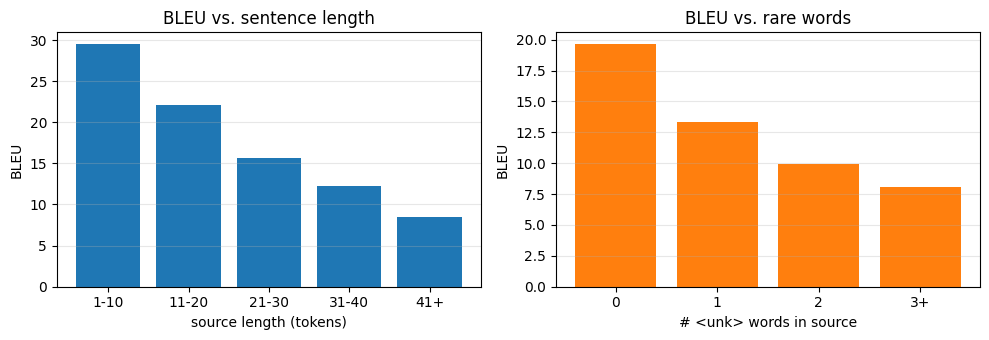

sentences containing repeated 3-grams in output: 18.5% (reference: 10.0%)
overall length ratio hyp/ref: 0.920


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].bar(len_report.src_len.astype(str), len_report.BLEU, color="tab:blue")
ax[0].set_xlabel("source length (tokens)"); ax[0].set_ylabel("BLEU"); ax[0].set_title("BLEU vs. sentence length")
ax[1].bar(unk_report.n_unk.astype(str), unk_report.BLEU, color="tab:orange")
ax[1].set_xlabel("# <unk> words in source"); ax[1].set_ylabel("BLEU"); ax[1].set_title("BLEU vs. rare words")
for a in ax: a.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

print(f"sentences containing repeated 3-grams in output: {100*test_df.repeats.mean():.1f}% "
      f"(reference: {100*test_df.fr_tok.map(has_repeat).mean():.1f}%)")
print(f"overall length ratio hyp/ref: {test_df.hyp_len.sum()/test_df.ref_len.sum():.3f}")

In [16]:
def show(rows, title):
    print("=" * 100, f"\n{title}\n", "=" * 100, sep="")
    for _, r in rows.iterrows():
        print(f"EN : {r.en}\nREF: {r.fr}\nHYP: {' '.join(r.hyp_tok)}\n")

show(test_df[test_df.src_len.between(5, 12)].sample(5, random_state=0), "Short sentences")
show(test_df[test_df.src_len >= 40].sample(3, random_state=0),          "Long sentences (>= 40 tokens)")
show(test_df[test_df.n_unk >= 2].sample(3, random_state=0),             "Sentences with >= 2 unknown source words")

Short sentences
EN : So what opened my eyes?
REF: Alors, qu'est-ce qui m'a ouvert les yeux ?
HYP: alors qu ' est - ce qui m ' a ouvert ?

EN : Other teams followed suit.
REF: D'autres équipes ont fait de même.
HYP: d ' autres équipes ont <unk> une combinaison .

EN : And the form has something to do with it.
REF: La forme y est aussi pour quelque chose.
HYP: et la forme a quelque chose à faire avec ça .

EN : He never made it there.
REF: Il n'est jamais arrivé.
HYP: il n ' a jamais fait ça .

EN : Oh, that's all my time?
REF: Oh, mon temps est terminé ?
HYP: oh , c ' est tout mon temps ?

Long sentences (>= 40 tokens)
EN : Years ago, when I was in graduate school,  one of my graduate advisers who knew I was interested in feminism --  I considered myself a feminist, as I still do --  asked a really strange question.
REF: il y a des années, quand j'étais à la fac, un de mes tuteurs qui savait que le féminisme m'intéressait, je me considérais comme une féministe, et c'est toujours le cas,

## 10. Summary

In [17]:
n_params = model.count_params()
summary = pd.DataFrame({
    "item": ["Architecture", "Parameters", "Vocab (EN / FR)", "Train pairs", "Decoding",
             "Best val loss (ppl)", "Test BLEU", "BLEU, sources 1-10 tokens", "BLEU, sources 41+ tokens"],
    "value": [f"{CFG.n_layers}-layer LSTM enc-dec, emb {CFG.emb_dim}, hid {CFG.hid_dim}, no attention",
              f"{n_params:,}", f"{len(src_vocab):,} / {len(tgt_vocab):,}", f"{len(train_df):,}", "greedy",
              f"{best_val:.3f} ({math.exp(best_val):.1f})", f"{test_bleu:.2f}",
              str(len_report.loc[len_report.src_len == "1-10", "BLEU"].values[:1]),
              str(len_report.loc[len_report.src_len == "41+", "BLEU"].values[:1])]})
display(summary)

,item,value
0,Architecture,"2-layer LSTM enc-dec, emb 256, hid 512, no att..."
1,Parameters,"23,748,224"
2,Vocab (EN / FR),"16,000 / 16,000"
3,Train pairs,"200,245"
4,Decoding,greedy
5,Best val loss (ppl),2.798 (16.4)
6,Test BLEU,16.57
7,"BLEU, sources 1-10 tokens",[29.46]
8,"BLEU, sources 41+ tokens",[8.44]
